<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Midterm_2_Part_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Midterm Part II: Drift compensation

**Authors:**

- Richard (Yu) Liu: https://github.com/RichardLiuCoding

- Sergei V. Kalinin: https://github.com/SergeiVKalinin






Real instruments always have drift due to the mechanical elements, sample motion, etc. Here, we want to build the cway to analyze and compensate the drift from the set of images.  

**Instructions:**

* Go to the section of ***"Example of images with generagted drift"***
* Click "Runtime" --> "Run above"
* Use the three examples in the ***"Example of images with generagted drift"*** as your sample drifting images, or
* Change parameters to generate your own ground-truth drifting fields and corresponding scan images

**Two ways to retrieve the distorted images:**

1. call the **get_image(x, y)** repeatedly to get the continuous scans at the specified location (x,y)

2. call the **get_image(x, y, i)** function to get the i-th scan at the location (x,y) by specifying the scan index i

# Imports

In [1]:
import scipy as sp
import numpy as np
# import aespm.tools as at
import matplotlib.pyplot as plt

# Define functions to generate atomic lattice

## Helper functions

In [2]:
# FT to show Bragg peaks

def fft(dataIn, window='None', output='absolute', zeroDC=False, beta=1.0,
        units='None'):
    '''
    Compute the fast Frouier transform of a data set with the option to add
    windowing.

    Inputs:
        dataIn    - Required : A 1D, 2D or 3D numpy array
        window  - Optional : String containing windowing function used to mask
                             data.  The options are: 'None' (or 'none'), 'bartlett',
                             'blackman', 'hamming', 'hanning' and 'kaiser'.
        output  - Optional : String containing desired form of output.  The
                             options are: 'absolute', 'real', 'imag', 'phase'
                             or 'complex'.
        zeroDC  - Optional : Boolean indicated if the centeral pixel of the
                                FFT will be set to zero.
        beta    - Optional : Float used to specify the kaiser window.  Only
                               used if window='kaiser'.
        units   - Optional : String containing desired units for the FFT.
                             Options: 'None', or 'amplitude' (in the future, I
                             might add "ASD" and "PSD".

    Returns:
        fftData - numpy array containing FFT of data

    Usage:
        fftData = fft(data, window='None', output='absolute', zeroDC=False,
                      beta=1.0)
    '''
    def ft2(data):
        ftData = np.fft.fft2(data)
        if zeroDC:
            ftData[0,0] = 0
        return np.fft.fftshift(ftData)

    outputFunctions = {'absolute':np.absolute, 'real':np.real,
                       'imag':np.imag, 'phase':np.angle, 'complex':(lambda x:x) }

    windowFunctions = {'None':(lambda x:np.ones(x)), 'none':(lambda x:np.ones(x)),
                       'bartlett':np.bartlett, 'blackman':np.blackman,
                       'hamming':np.hamming, 'hanning':np.hanning,
                       'kaiser':np.kaiser }

    outputFunction = outputFunctions[output]
    windowFunction = windowFunctions[window]

    data = dataIn.copy()
    if zeroDC:
        if len(data.shape) == 3:
            for ix, layer in enumerate(data):
                data[ix] -= np.mean(layer)
        else:
            data -= np.mean(data)

    if len(data.shape) != 1:
        if window == 'kaiser':
            wX = windowFunction(data.shape[-2], beta)[:,None]
            wY = windowFunction(data.shape[-1], beta)[None,:]
        else:
            wX = windowFunction(data.shape[-2])[:,None]
            wY = windowFunction(data.shape[-1])[None,:]
        W = wX * wY
        if len(data.shape) == 2:
            wData = data * W
            ftData = outputFunction(ft2(wData))
        elif len(data.shape) == 3:
            wTile = np.tile(W, (data.shape[0],1,1))
            wData = data * wTile
            if output == 'complex':
                ftData = np.zeros_like(data, dtype=np.complex)
            else:
                ftData = np.zeros_like(data)
            for ix, layer in enumerate(wData):
                ftData[ix] = outputFunction(ft2(layer))
        else:
            print('ERR: Input must be 1D, 2D or 3D numpy array')

    else:
        if window == 'kaiser':
            W = windowFunction(data.shape[0], beta)
        else:
            W = windowFunction(data.shape[0])
        wData = data * W
        ftD = np.fft.fft(wData)
        ftData = outputFunction(np.fft.fftshift(ftD))
    if units == 'amplitude':
        if len(data.shape) == 3:
            datashape = data[0].shape
        else:
            datashape = data.shape
        for size in datashape:
            ftData /= size
            if window == 'hanning':
                ftData *= 2
            elif window == 'None' or window == 'none':
                pass
            else:
                print('WARNING: The window function "%s" messes up the FT units' %
                        window)
    return ftData

def ifft(data, output='real', envelope=False):
    '''
    Compute the inverse Fourier transform with the option to detect envelope.

    Inputs:
        data    - Required : A 1D or 2D numpy array. (3D not yet supported)
        output  - Optional : String containing desired form of output.  The
                             options are: 'absolute', 'real', 'imag', 'phase'
                             or 'complex'.
        envelope - Optional : Boolen, when True applies the Hilbert transform
                              to detect the envelope of the IFT, which is the
                              absolute values.
        **kwarg - Optional : Passed to scipy.signal.hilbert()

    See docs.scipy.org/doc/scipy/reference/generated/scipy.signal.hilbert.html
    for more information about envelope function.

    Outputs:
        ift - A numpy array containing inverse Fourier transform.

    History:
        Adapted from stmpy
    '''
    outputFunctions = {'absolute':np.absolute, 'real':np.real,
                       'imag':np.imag, 'phase':np.angle, 'complex':(lambda x:x)}
    out = outputFunctions[output]
    if len(data.shape) == 2:
        ift = np.fft.ifft2(np.fft.ifftshift(data))
    elif len(data.shape) == 1:
        ift = np.fft.ifft(np.fft.ifftshift(data))
    if envelope:
        ift = hilbert(np.real(ift))
    return out(ift)


def fftfreq(px, nm):
    '''Get frequnecy bins for Fourier transform.'''
    freqs = np.fft.fftfreq(px, float(nm)/(px))
    return np.fft.fftshift(freqs)

In [3]:
# quick_display function
def quick_display(A, sigma=3):
    A_fft = fft(A, zeroDC=True)
    L = np.shape(A)[-1]
    c = np.mean(A_fft)
    s = np.std(A_fft)
    fig,ax=plt.subplots(2,2,figsize=[8, 8])
    ax[0, 0].imshow(A, cmap=plt.cm.Blues, origin='lower')
    ax[0, 0].axhline(L/2, color='r', linestyle='--')
    ax[0, 1].imshow(A_fft, cmap=plt.cm.gray_r, origin='lower', clim=[0,c+sigma*s])
    ax[0, 1].axhline(L/2, color='b', linestyle='--')
    ax[1, 0].plot(A[int(L/2)], 'r')
    ax[1, 0].plot(A[int(L/2)], 'rx', ms=4, mew=1)
    ax[1, 1].plot(A_fft[int(L/2)], 'b')
    ax[1, 1].plot(A_fft[int(L/2)], 'bx', ms=4, mew=1)

## Class to generate lattice

In [4]:
import numpy as np


class RectPeriodicLattice:
    """
    Rectangular periodic lattice generator in Cartesian x/y image coordinates.

    Supports:
      - square
      - triangular
      - honeycomb

    Main idea:
      Instead of storing only an array of positions, we store a registry of sites.
      Each site is a dict with:
          id         : stable integer site index
          ijk        : lattice integer indices / labels
          xy         : Cartesian coordinate (x, y)
          amp        : site amplitude (default 1.0)
          occupied   : whether this site is occupied
          kind       : "host" or e.g. "impurity"
          meta       : optional user metadata dict

    This makes it easy to:
      - remove a site by index
      - modify a site amplitude
      - replace a host atom by an impurity
      - access lattice coordinates of each site
    """

    def __init__(
        self,
        lattice="square",
        a=1.0,
        mx=16,
        my=16,
        Nx=512,
        Ny=512,
        sigma=0.1,
    ):
        self.lattice = lattice.lower()
        self.a = float(a)
        self.mx = int(mx)
        self.my = int(my)
        self.Nx = int(Nx)
        self.Ny = int(Ny)
        self.sigma = float(sigma)

        if self.lattice == "square":
            self.Lx = self.mx * self.a
            self.Ly = self.my * self.a

        elif self.lattice == "triangular":
            if self.mx % 2 != 0:
                raise ValueError("For rectangular periodic triangular lattice, mx must be even.")
            self.Lx = self.mx * self.a
            self.Ly = self.my * np.sqrt(3) * self.a

        elif self.lattice in ["honeycomb", "hexagonal"]:
            if self.mx % 2 != 0:
                raise ValueError("For rectangular periodic honeycomb lattice, mx must be even.")
            self.Lx = self.mx * np.sqrt(3) * self.a
            self.Ly = self.my * 3.0 * self.a
        else:
            raise ValueError("Unknown lattice type.")

        self.sites = self._generate_sites()
        self._rebuild_position_cache()

    # ------------------------------------------------------------------
    # site generation
    # ------------------------------------------------------------------
    def _generate_sites(self):
        """
        Return a list of site dictionaries.
        """
        raw_sites = []

        if self.lattice == "square":
            site_id = 0
            for i in range(self.mx):
                for j in range(self.my):
                    x = i * self.a
                    y = j * self.a
                    raw_sites.append(
                        self._make_site(
                            site_id=site_id,
                            ijk=(i, j, 0),
                            xy=(x, y),
                            amp=1.0,
                            occupied=True,
                            kind="host",
                        )
                    )
                    site_id += 1

        elif self.lattice == "triangular":
            # rectangular supercell, row spacing sqrt(3)/2 * a
            nrows = 2 * self.my
            site_id = 0
            for j in range(nrows):
                y = j * (np.sqrt(3) * 0.5 * self.a)
                xshift = 0.5 * self.a if (j % 2 == 1) else 0.0
                for i in range(self.mx):
                    x = (i * self.a + xshift) % self.Lx
                    raw_sites.append(
                        self._make_site(
                            site_id=site_id,
                            ijk=(i, j, 0),
                            xy=(x, y % self.Ly),
                            amp=1.0,
                            occupied=True,
                            kind="host",
                        )
                    )
                    site_id += 1

        elif self.lattice in ["honeycomb", "hexagonal"]:
            # triangular Bravais + 2-site basis
            a1 = np.array([np.sqrt(3) * self.a, 0.0])
            a2 = np.array([0.5 * np.sqrt(3) * self.a, 1.5 * self.a])
            basis = [
                np.array([0.0, 0.0]),                                  # sublattice A
                np.array([0.5 * np.sqrt(3) * self.a, 0.5 * self.a]),   # sublattice B
            ]

            n1 = self.mx
            n2 = 2 * self.my

            site_id = 0
            for i in range(n1):
                for j in range(n2):
                    R = i * a1 + j * a2
                    for s, b in enumerate(basis):
                        r = R + b
                        x = r[0] % self.Lx
                        y = r[1] % self.Ly
                        raw_sites.append(
                            self._make_site(
                                site_id=site_id,
                                ijk=(i, j, s),
                                xy=(x, y),
                                amp=1.0,
                                occupied=True,
                                kind="host",
                            )
                        )
                        site_id += 1

        # remove periodic duplicates while keeping metadata
        return self._deduplicate_sites(raw_sites)

    def _make_site(self, site_id, ijk, xy, amp=1.0, occupied=True, kind="host", meta=None):
        return {
            "id": int(site_id),
            "ijk": tuple(ijk),                       # lattice/cell/sublattice index
            "xy": np.array(xy, dtype=float),        # Cartesian coordinate
            "amp": float(amp),
            "occupied": bool(occupied),
            "kind": str(kind),
            "meta": {} if meta is None else dict(meta),
        }

    def _deduplicate_sites(self, sites, tol_decimals=12):
        """
        Remove periodic duplicates created by wrapping. Keep first occurrence.
        Reassign ids after deduplication so ids are contiguous.
        """
        seen = {}
        unique_sites = []

        for site in sites:
            key = tuple(np.round(site["xy"], tol_decimals))
            if key not in seen:
                seen[key] = True
                unique_sites.append(site)

        # reassign ids to be contiguous
        for new_id, site in enumerate(unique_sites):
            site["id"] = new_id

        return unique_sites

    def _rebuild_position_cache(self):
        """
        Build fast numpy caches from the site registry.
        """
        active_sites = [s for s in self.sites if s["occupied"]]

        if len(active_sites) == 0:
            self.positions = np.zeros((0, 2), dtype=float)
            self.site_ids_active = np.zeros((0,), dtype=int)
            self.site_amplitudes_active = np.zeros((0,), dtype=float)
            return

        self.positions = np.array([s["xy"] for s in active_sites], dtype=float)
        self.site_ids_active = np.array([s["id"] for s in active_sites], dtype=int)
        self.site_amplitudes_active = np.array([s["amp"] for s in active_sites], dtype=float)

    # ------------------------------------------------------------------
    # querying / editing sites
    # ------------------------------------------------------------------
    def get_site(self, site_id):
        return self.sites[site_id]

    def get_site_xy(self, site_id):
        return self.sites[site_id]["xy"].copy()

    def get_site_ijk(self, site_id):
        return self.sites[site_id]["ijk"]

    def set_site_amplitude(self, site_id, amp):
        self.sites[site_id]["amp"] = float(amp)
        self._rebuild_position_cache()

    def remove_atom(self, site_id):
        """
        Mark a site as vacant without deleting it from the registry.
        This preserves stable site indexing.
        """
        self.sites[site_id]["occupied"] = False
        self.sites[site_id]["kind"] = "vacancy"
        self._rebuild_position_cache()

    def restore_atom(self, site_id, amp=1.0, kind="host"):
        self.sites[site_id]["occupied"] = True
        self.sites[site_id]["amp"] = float(amp)
        self.sites[site_id]["kind"] = str(kind)
        self._rebuild_position_cache()

    def add_impurity_to_site(self, site_id, amp=None, kind="impurity", **meta):
        """
        Replace or decorate a site as an impurity.
        """
        self.sites[site_id]["occupied"] = True
        self.sites[site_id]["kind"] = str(kind)
        if amp is not None:
            self.sites[site_id]["amp"] = float(amp)
        self.sites[site_id]["meta"].update(meta)
        self._rebuild_position_cache()

    def add_adatom(self, xy, amp=1.0, kind="adatom", **meta):
        """
        Add a completely new off-lattice atom/adatom at arbitrary position.
        """
        xy = np.asarray(xy, dtype=float).copy()
        xy[0] %= self.Lx
        xy[1] %= self.Ly

        new_id = len(self.sites)
        self.sites.append(
            self._make_site(
                site_id=new_id,
                ijk=(-1, -1, -1),   # indicates not tied to native lattice indexing
                xy=xy,
                amp=amp,
                occupied=True,
                kind=kind,
                meta=meta,
            )
        )
        self._rebuild_position_cache()
        return new_id

    def list_sites(self, occupied_only=False):
        if occupied_only:
            return [s.copy() for s in self.sites if s["occupied"]]
        return [s.copy() for s in self.sites]

    # ------------------------------------------------------------------
    # rendering
    # ------------------------------------------------------------------
    def render(self, amp=1.0, site_amplitudes=None, occupied_only=True):
        """
        Render lattice as a sum of Gaussians.

        Parameters
        ----------
        amp : float
            Default amplitude if site_amplitudes is None and per-site amps
            are not used.
        site_amplitudes : array-like or None
            Optional override amplitudes for the ACTIVE sites only.
        occupied_only : bool
            If True, render only occupied sites. Usually what you want.
        """
        x = np.arange(self.Nx) * self.Lx / self.Nx
        y = np.arange(self.Ny) * self.Ly / self.Ny
        xx, yy = np.meshgrid(x, y)

        z = np.zeros((self.Ny, self.Nx), dtype=float)

        if occupied_only:
            sites_to_render = [s for s in self.sites if s["occupied"]]
        else:
            sites_to_render = self.sites

        if len(sites_to_render) == 0:
            return z

        pos = np.array([s["xy"] for s in sites_to_render], dtype=float)

        if site_amplitudes is None:
            # use per-site stored amplitudes
            amps = np.array([s["amp"] for s in sites_to_render], dtype=float) * amp
        else:
            amps = np.asarray(site_amplitudes, dtype=float)
            if len(amps) != len(pos):
                raise ValueError("site_amplitudes must have the same length as rendered sites.")

        for (x0, y0), a0 in zip(pos, amps):
            dx = xx - x0
            dy = yy - y0

            dx = dx - self.Lx * np.round(dx / self.Lx)
            dy = dy - self.Ly * np.round(dy / self.Ly)

            z += a0 * np.exp(-(dx**2 + dy**2) / (2 * self.sigma**2))

        return z

    # ------------------------------------------------------------------
    # nearest-site lookup
    # ------------------------------------------------------------------
    def snap_to_nearest_site(self, center_xy, occupied_only=True):
        """
        Return:
            xy_nearest, site_id, site_dict
        """
        center = np.asarray(center_xy, dtype=float)

        if occupied_only:
            candidate_sites = [s for s in self.sites if s["occupied"]]
        else:
            candidate_sites = self.sites

        if len(candidate_sites) == 0:
            raise ValueError("No candidate sites available.")

        pos = np.array([s["xy"] for s in candidate_sites], dtype=float)
        ids = np.array([s["id"] for s in candidate_sites], dtype=int)

        dxy = pos - center[None, :]
        dxy[:, 0] -= self.Lx * np.round(dxy[:, 0] / self.Lx)
        dxy[:, 1] -= self.Ly * np.round(dxy[:, 1] / self.Ly)
        d2 = np.sum(dxy**2, axis=1)

        k = np.argmin(d2)
        site_id = int(ids[k])
        return self.sites[site_id]["xy"].copy(), site_id, self.sites[site_id].copy()

# Simulate the drifting field

## Generate base drift field

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def make_coordinate_grid(nx, ny):
    y = np.arange(ny)
    x = np.arange(nx)
    Y, X = np.meshgrid(y, x, indexing='ij')
    return X, Y


def normalize_direction(theta):
    return np.cos(theta), np.sin(theta)


def generate_base_exponential_drift(
    nx,
    ny,
    amp0=8.0,
    tau_x=80.0,
    tau_y=120.0,
    theta=np.deg2rad(20),
    mode='or',
):
    """
    Generate a base exponential drift field.

    Parameters
    ----------
    nx, ny : int
        Image size.
    amp0 : float
        Overall drift amplitude in pixels.
    tau_x, tau_y : float
        Decay lengths along x and y.
    theta : float
        Drift direction in radians.
    mode : str
        How the x- and y-decay contributions are combined.

        'product' : large only when both x and y are small
                    A ~ exp(-x/tau_x) * exp(-y/tau_y)

        'or'      : large when x is small OR y is small
                    A ~ exp(-x/tau_x) + exp(-y/tau_y)

        'x_only'  : large for all small x
                    A ~ exp(-x/tau_x)

        'y_only'  : large for all small y
                    A ~ exp(-y/tau_y)

    Returns
    -------
    ux, uy : 2D ndarray
        Drift field components in pixels.
    """
    X, Y = make_coordinate_grid(nx, ny)

    fx = np.exp(-X / tau_x)
    fy = np.exp(-Y / tau_y)

    if mode == 'product':
        amplitude = amp0 * fx * fy
    elif mode == 'or':
        amplitude = amp0 * (fx + fy)
    elif mode == 'x_only':
        amplitude = amp0 * fx
    elif mode == 'y_only':
        amplitude = amp0 * fy
    else:
        raise ValueError("mode must be one of: 'product', 'or', 'x_only', 'y_only'")

    dx, dy = normalize_direction(theta)
    ux = amplitude * dx
    uy = amplitude * dy
    return ux, uy

def plot_drift_fields(ux, uy, title=''):
    mag = np.sqrt(ux**2 + uy**2)

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
    im0 = ax[0].imshow(ux, origin='lower', cmap='coolwarm')
    ax[0].set_title(r'$u_x$')
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(uy, origin='lower', cmap='coolwarm')
    ax[1].set_title(r'$u_y$')
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(mag, origin='lower', cmap='viridis')
    ax[2].set_title(r'$|u|$')
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Generate drift field with random event

In [6]:
def generate_drift_with_random_events(
    nx,
    ny,
    amp0=8.0,
    tau_x=80.0,
    tau_y=120.0,
    theta=np.deg2rad(20),
    n_events=8,
    event_amp_range=(2.0, 8.0),
    event_sigma_range=(4.0, 14.0),
    random_theta_std_deg=35.0,
    seed=None,
):
    """
    Scenario 2:
    Same as scenario 1, but add random large drift events,
    each spatially smoothed with a Gaussian shape.

    The events are local bursts in the displacement field.
    """
    rng = np.random.default_rng(seed)

    ux, uy = generate_base_exponential_drift(
        nx=nx,
        ny=ny,
        amp0=amp0,
        tau_x=tau_x,
        tau_y=tau_y,
        theta=theta,
    )

    X, Y = make_coordinate_grid(nx, ny)

    for _ in range(n_events):
        # Bias events toward early scan region
        x0 = rng.uniform(0, 0.4 * nx)
        y0 = rng.uniform(0, 0.4 * ny)

        event_amp = rng.uniform(*event_amp_range)
        sigma = rng.uniform(*event_sigma_range)

        # Event direction = base direction + random offset
        dtheta = np.deg2rad(rng.normal(0, random_theta_std_deg))
        theta_evt = theta + dtheta
        dx_evt, dy_evt = normalize_direction(theta_evt)

        G = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

        ux += event_amp * dx_evt * G
        uy += event_amp * dy_evt * G

    return ux, uy

## Generate drift field with thermal drifting

In [7]:



import numpy as np
from scipy.ndimage import gaussian_filter

def generate_drift_with_thermal_component(
    nx,
    ny,
    amp0=10.0,
    tau_x=70.0,
    tau_y=110.0,
    theta_base=np.deg2rad(30),
    thermal_amp_x=2.0,
    thermal_tau_x=120.0,
    thermal_amp_y=1.5,
    thermal_tau_y=140.0,
    t=0.0,
    omega=1.0,
    phi_x=0.0,
    thermal_noise_amp=0.12,
    thermal_smooth_sigma=10.0,
    seed=1,
):
    """
    Drift field with:
      1) base exponentially decaying drift
      2) thermal drift:
           ux_th ~ exp(-x/thermal_tau_x) * cos(omega*t + phi_x)
           uy_th ~ exp(-y/thermal_tau_y)
      3) optional smooth random perturbation

    Returns
    -------
    ux, uy : 2D arrays, shape (ny, nx)
    """
    rng = np.random.default_rng(seed)

    y = np.arange(ny)
    x = np.arange(nx)
    Y, X = np.meshgrid(y, x, indexing='ij')

    # --------------------------------------------------
    # Base drift (same idea as before)
    # --------------------------------------------------
    amplitude = amp0 * np.exp(-X / tau_x) * np.exp(-Y / tau_y)
    ux_base = amplitude * np.cos(theta_base)
    uy_base = amplitude * np.sin(theta_base)

    # --------------------------------------------------
    # Thermal drift you requested
    # --------------------------------------------------
    ux_th = thermal_amp_x * np.exp(-X / thermal_tau_x) * np.cos(omega * t + phi_x)
    uy_th = thermal_amp_y * np.exp(-Y / thermal_tau_y)

    # --------------------------------------------------
    # Small smooth random fluctuations
    # --------------------------------------------------
    noise_x = rng.normal(size=(ny, nx))
    noise_y = rng.normal(size=(ny, nx))

    noise_x = gaussian_filter(noise_x, sigma=thermal_smooth_sigma)
    noise_y = gaussian_filter(noise_y, sigma=thermal_smooth_sigma)

    noise_x /= (np.std(noise_x) + 1e-12)
    noise_y /= (np.std(noise_y) + 1e-12)

    ux = ux_base + ux_th + thermal_noise_amp * noise_x
    uy = uy_base + uy_th + thermal_noise_amp * noise_y

    return ux, uy

## Combining everything together

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


# ------------------------------------------------------------
# 1. Build a large parent image z_initial
# ------------------------------------------------------------
def make_large_lattice_map(
    mx=120,
    my=120,
    Nx=1024,
    Ny=1024,
    sigma=0.20,
    n_vacancies=120,
    n_adatoms=180,
    seed=0,
):
    """
    Create a large periodic lattice image with vacancies and adatoms.

    Returns
    -------
    z_initial : 2D ndarray, shape (Ny, Nx)
    sim : RectPeriodicLattice object
    """
    sim = RectPeriodicLattice(
        lattice="square",
        a=1.0,
        mx=mx,
        my=my,
        Nx=Nx,
        Ny=Ny,
        sigma=sigma,
    )

    rng = np.random.default_rng(seed)

    # remove random atoms
    vacancy_ids = rng.choice(len(sim.sites), size=n_vacancies, replace=False)
    for site_id in vacancy_ids:
        sim.remove_atom(int(site_id))

    # choose random lattice sites and place adatoms
    host_ids = rng.choice(len(sim.sites), size=n_adatoms, replace=False)
    for site_id in host_ids:
        xy = sim.get_site_xy(int(site_id))
        sim.add_adatom(
            xy=xy,
            amp=1.0,
            kind="adatom",
        )

    z_initial = sim.render()
    return z_initial, sim



import numpy as np
from scipy.ndimage import gaussian_filter


def make_thermal_drift_trajectory(
    n_steps=1000,
    mode=0,
    r0=20.0,                         # initial radius / amplitude
    k=0.02,                          # linear shrink rate for spiral
    omega=0.15,                      # angular frequency
    tau=200.0,                       # exponential decay timescale
    theta_thermal=np.deg2rad(80),    # direction for exp_decay
    thermal_noise_amp=0.15,          # amplitude of small variations
    thermal_smooth_sigma=12.0,       # smoothness in time
    seed=1,
    clip_radius_at_zero=True,
):
    """
    Create a time-dependent drift trajectory dx(i), dy(i).

    Returns
    -------
    dx_t, dy_t : 1D arrays of length n_steps
        Drift trajectory in pixel units.
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps, dtype=float)

    # --------------------------------------------------
    # Deterministic drift
    # --------------------------------------------------
    if mode == 0:
        radius = r0 - k * t
        if clip_radius_at_zero:
            radius = np.maximum(radius, 0.0)

        dx_det = radius * np.cos(omega * t)
        dy_det = radius * np.sin(omega * t)

    elif mode == 1:
        radius = r0 * np.exp(-t / tau)
        dx_det = radius * np.cos(omega * t)
        dy_det = radius * np.sin(omega * t)

    elif mode == 2:
        amp = r0 * np.exp(-t / tau)
        dx_det = amp * np.cos(theta_thermal)
        dy_det = amp * np.sin(theta_thermal)

    else:
        raise ValueError("mode must be 'spiral', 'exp_spiral', or 'exp_decay'")

    # --------------------------------------------------
    # Small smooth fluctuations in time
    # --------------------------------------------------
    noise_x = rng.normal(size=n_steps)
    noise_y = rng.normal(size=n_steps)

    noise_x = gaussian_filter(noise_x, sigma=thermal_smooth_sigma)
    noise_y = gaussian_filter(noise_y, sigma=thermal_smooth_sigma)

    noise_x /= (np.std(noise_x) + 1e-12)
    noise_y /= (np.std(noise_y) + 1e-12)

    dx_t = dx_det + thermal_noise_amp * noise_x
    dy_t = dy_det + thermal_noise_amp * noise_y

    return dx_t, dy_t


import numpy as np
from scipy.ndimage import map_coordinates

def crop_periodic_center(z, xc, yc, out_Nx=256, out_Ny=256, order=3):
    """
    Crop a periodic image centered at non-integer (xc, yc), allowing wrap-around
    and sub-pixel shifts through interpolation.

    Parameters
    ----------
    z : 2D ndarray, shape (Ny, Nx)
        Large parent image
    xc, yc : float
        Crop center in pixel coordinates of the large image
    out_Nx, out_Ny : int
        Output crop size
    order : int
        Interpolation order:
            0 = nearest
            1 = linear
            3 = cubic (good default)

    Returns
    -------
    patch : 2D ndarray, shape (out_Ny, out_Nx)
    """
    Ny, Nx = z.shape

    # local output coordinates centered around (0, 0)
    yy, xx = np.meshgrid(
        np.arange(out_Ny) - out_Ny // 2,
        np.arange(out_Nx) - out_Nx // 2,
        indexing='ij'
    )

    # source coordinates in the large image
    x_src = xc + xx
    y_src = yc + yy

    # periodic wrapping
    x_src = np.mod(x_src, Nx)
    y_src = np.mod(y_src, Ny)

    # sample with interpolation
    patch = map_coordinates(
        z,
        [y_src, x_src],
        order=order,
        mode='wrap'
    )

    return patch


def make_image_getter(
    z_initial,
    out_Nx=256,
    out_Ny=256,
    n_steps=1000,
    thermal_speed=0.35,
    r0=100.0,                       # initial radius / amplitude
    k=0.3,                          # linear shrink rate for spiral
    omega=0.18,                     # angular frequency
    tau=25.0,                       # exponential decay timescale
    theta_thermal=np.deg2rad(80),
    thermal_noise_amp=0.15,
    thermal_smooth_sigma=12.0,
    seed=1,
    distortion=False,
    mode=0,
):
    """
    Returns
    -------
    get_image : callable
        get_image(x, y, i=None, return_info=False, distortion=False)
    reset_time : callable
        reset internal frame counter
    get_drift_trace : callable
        returns copies of the exact dx_t, dy_t used internally
    gt_drift_fn : callable
        gt_drift_fn(i) -> (dx, dy), using the exact same drift arrays as get_image
    """
    Ny, Nx = z_initial.shape
    x0_global = Nx // 2
    y0_global = Ny // 2

    # Exact drift trace used by get_image
    dx_t, dy_t = make_thermal_drift_trajectory(
        n_steps=n_steps,
        mode=mode,
        r0=r0,
        k=k,
        omega=omega,
        tau=tau,
        theta_thermal=theta_thermal,
        thermal_noise_amp=thermal_noise_amp,
        thermal_smooth_sigma=thermal_smooth_sigma,
        seed=seed,
    )

    state = {"i": 0}

    def gt_drift_fn(i):
        """
        Ground-truth rigid drift at time step i.

        Convention:
        - if get_image(..., i=None) starts at internal state 0,
          then gt_drift_fn(0) matches the first image.
        - if you call get_image(..., i=17), then gt_drift_fn(17)
          gives the exact rigid drift used in that image.
        """
        if i != int(i):
            raise ValueError("i must be an integer")
        i_use = int(i) % n_steps
        return float(dx_t[i_use]), float(dy_t[i_use])

    def get_image(x, y, i=None, return_info=False, distortion=False):
        """
        Parameters
        ----------
        x, y : int
            Requested image-center position in pixels relative to the
            center of z_initial.
        i : int or None
            Time step. If None, uses and increments internal counter.
        return_info : bool
            If True, also return metadata dict.
        distortion : bool
            If True, apply additional non-rigid image distortion.

        Returns
        -------
        img : 2D ndarray
            Cropped image
        info : dict, optional
            Contains actual time step and applied drift
        """
        # if x != int(x) or y != int(y):
        #     raise ValueError("x and y must be integers")

        x = float(x)
        y = float(y)

        if i is None:
            i_use = state["i"]
            state["i"] += 1
        else:
            if i != int(i):
                raise ValueError("i must be an integer")
            i_use = int(i)

        i_use = i_use % n_steps

        # Exact rigid drift used for this image
        dx = dx_t[i_use]
        dy = dy_t[i_use]

        # actual crop center in the large parent image
        xc = x0_global + x + dx
        yc = y0_global + y + dy

        if xc < 0 or xc >= Nx or yc < 0 or yc >= Ny:
            raise ValueError("Crop center is outside the parent image")

        img = crop_periodic_center(
            z_initial,
            xc=xc,
            yc=yc,
            out_Nx=out_Nx,
            out_Ny=out_Ny,
        )

        distortion_info = None
        if distortion:
            ux, uy = generate_drift_with_thermal_component(
                nx=out_Nx,
                ny=out_Ny,
                amp0=0.0,
                thermal_amp_x=2.0,
                thermal_tau_x=120.0,
                thermal_amp_y=1.5,
                thermal_tau_y=140.0,
                t=i_use,
                omega=0.2,
                thermal_noise_amp=0.05,
                thermal_smooth_sigma=10.0,
                seed=1,
            )
            img = distort_image_with_drift(img, ux, uy, order=3)
            distortion_info = {"ux_field": ux, "uy_field": uy}

        if return_info:
            info = {
                "i": i_use,
                "requested_center": (x, y),
                "thermal_shift": (float(dx), float(dy)),
                "actual_center_in_parent": (float(xc), float(yc)),
                "distortion": distortion_info,
            }
            return img, info

        return img

    def reset_time(i0=0):
        state["i"] = int(i0)

    def get_drift_trace():
        return dx_t.copy(), dy_t.copy()

    return get_image, reset_time, get_drift_trace, gt_drift_fn

In [9]:
def check_image(img1, img2):
  return np.mean(np.abs(img1 - img2))

# Example of images with generated drifts

## Generate square lattice with defects

In [10]:
# Large parent map
z_initial, sim_large = make_large_lattice_map(
    mx=60, my=60,     # map size in nm
    Nx=512, Ny=512,   # map size in pixels
    sigma=0.20,       # radius of atoms, ratio to the atomic distance
    n_vacancies=150,  # number of vacancies
    n_adatoms=200,    # number of adatoms
    seed=0,
)


## Get time-dependent images with drift

## Drift field-1

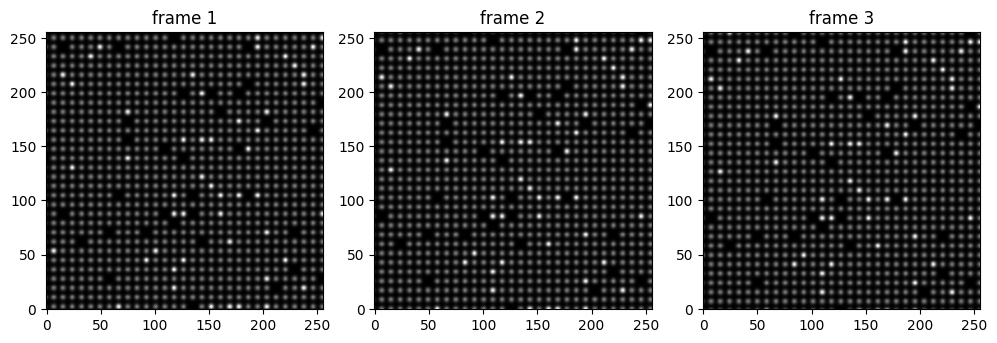

In [11]:

# Build the stateful image getter
get_image1, reset_time1, get_drift_trace1, gt_drift_fn1 = make_image_getter(
    z_initial,                        # large-scale ground truth generated by make_large_lattice_map()
    out_Nx=256, out_Ny=256,           # cropped smaller image with drift
    n_steps=1000,                     # number of total time steps
    r0=10.0,                          # initial drift amplitude
    k=0.1,                            # linear shrink rate for spiral
    omega=0.18,                       # angular frequency
    tau=25.0,                         # exponential decay timescale
    theta_thermal=np.deg2rad(80),     # direction of the thermal drift
    thermal_noise_amp=0.5,              # amplitude of thermal noise
    thermal_smooth_sigma=2.50,         # smoothness of thermal noise
    seed=1,
    mode=0,                           # different drift functions
)

# Example: same nominal center, three successive frames
img1 = get_image1(0, 0, 65)
img2 = get_image1(0, 0)
img3 = get_image1(0, 0)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(img1, cmap='gray', origin='lower')
ax[0].set_title("frame 1")
ax[1].imshow(img2, cmap='gray', origin='lower')
ax[1].set_title("frame 2")
ax[2].imshow(img3, cmap='gray', origin='lower')
ax[2].set_title("frame 3")
plt.tight_layout()
plt.show()

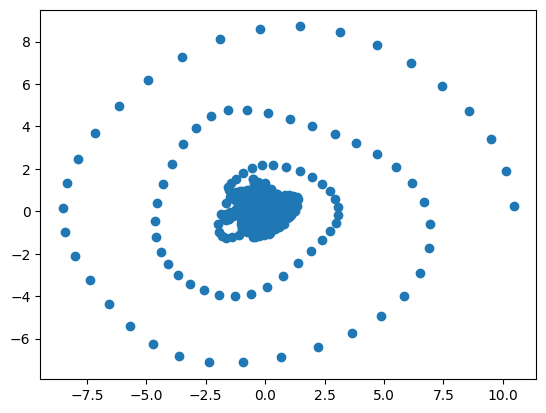

In [12]:
plt.scatter(get_drift_trace1()[0], get_drift_trace1()[1])

## Drift field-2

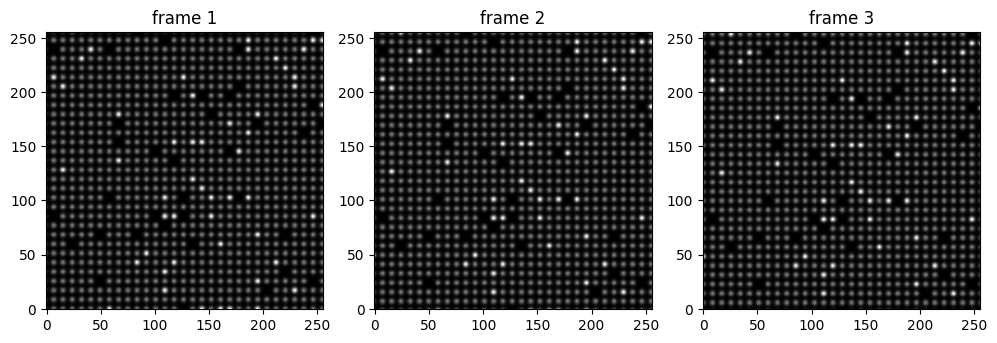

In [13]:

# Build the stateful image getter
get_image2, reset_time2, get_drift_trace2, gt_drift_fn2 = make_image_getter(
    z_initial,                        # large-scale ground truth generated by make_large_lattice_map()
    out_Nx=256, out_Ny=256,           # cropped smaller image with drift
    n_steps=1000,                     # number of total time steps
    r0=10.0,                         # initial drift amplitude
    k=0.1,                            # linear shrink rate for spiral
    omega=0.18,                       # angular frequency
    tau=20.0,                         # exponential decay timescale
    theta_thermal=np.deg2rad(80),     # direction of the thermal drift
    thermal_noise_amp=0.5,              # amplitude of thermal noise
    thermal_smooth_sigma=2.50,         # smoothness of thermal noise
    seed=1,
    mode=1,                           # different drift functions
)

# Example: same nominal center, three successive frames
img1 = get_image2(0, 0)
img2 = get_image2(0, 0)
img3 = get_image2(0, 0)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(img1, cmap='gray', origin='lower')
ax[0].set_title("frame 1")
ax[1].imshow(img2, cmap='gray', origin='lower')
ax[1].set_title("frame 2")
ax[2].imshow(img3, cmap='gray', origin='lower')
ax[2].set_title("frame 3")
plt.tight_layout()
plt.show()

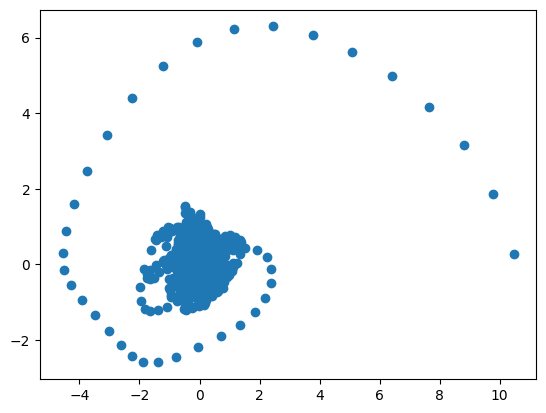

In [14]:
plt.scatter(get_drift_trace2()[0], get_drift_trace2()[1])

## Drift field-3

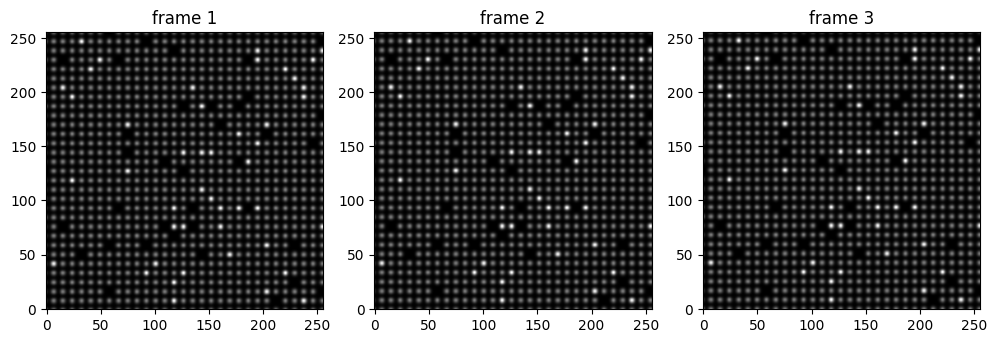

In [15]:

# Build the stateful image getter
get_image3, reset_time3, get_drift_trace3, gt_drift_fn3 = make_image_getter(
    z_initial,                        # large-scale ground truth generated by make_large_lattice_map()
    out_Nx=256, out_Ny=256,           # cropped smaller image with drift
    n_steps=1000,                     # number of total time steps
    r0=10.0,                         # initial drift amplitude
    k=0.1,                            # linear shrink rate for spiral
    omega=0.18,                       # angular frequency
    tau=25.0,                         # exponential decay timescale
    theta_thermal=np.deg2rad(80),     # direction of the thermal drift
    thermal_noise_amp=0.25,              # amplitude of thermal noise
    thermal_smooth_sigma=2.50,         # smoothness of thermal noise
    seed=1,
    mode=2,                           # different drift functions
)

# Example: same nominal center, three successive frames
img1 = get_image3(0, 0)
img2 = get_image3(0, 0)
img3 = get_image3(0, 0)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(img1, cmap='gray', origin='lower')
ax[0].set_title("frame 1")
ax[1].imshow(img2, cmap='gray', origin='lower')
ax[1].set_title("frame 2")
ax[2].imshow(img3, cmap='gray', origin='lower')
ax[2].set_title("frame 3")
plt.tight_layout()
plt.show()

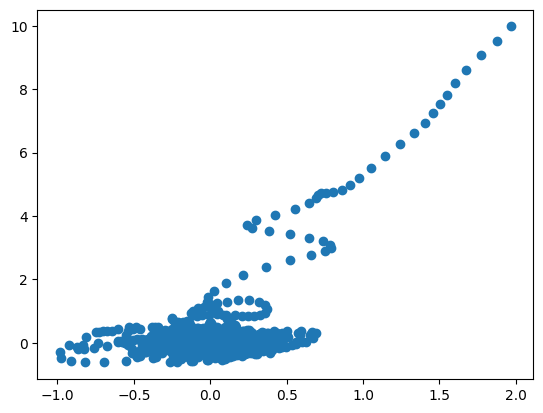

In [16]:
plt.scatter(get_drift_trace3()[0], get_drift_trace3()[1])

## Drift fields after many steps

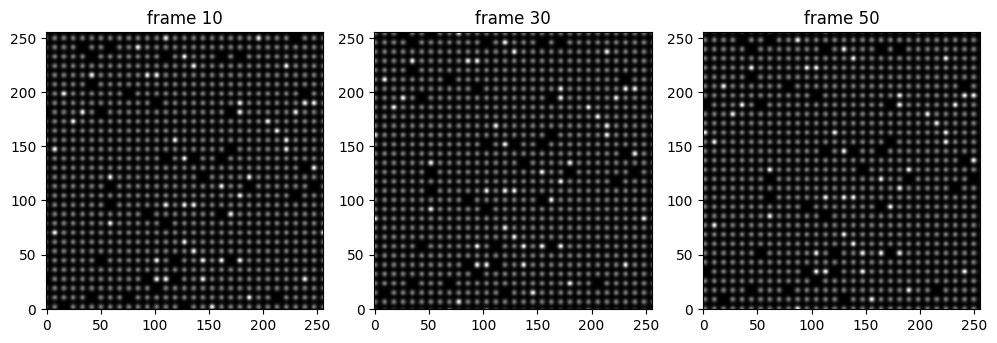

In [17]:
# Alternatively, you can specify what time steps and centers you want to image

# Example: same nominal center, three successive frames
img1 = get_image1(20, 50, i=10)
img2 = get_image1(20, 50, i=30)
img3 = get_image1(20, 50, i=50)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(img1, cmap='gray', origin='lower')
ax[0].set_title("frame 10")
ax[1].imshow(img2, cmap='gray', origin='lower')
ax[1].set_title("frame 30")
ax[2].imshow(img3, cmap='gray', origin='lower')
ax[2].set_title("frame 50")
plt.tight_layout()
plt.show()

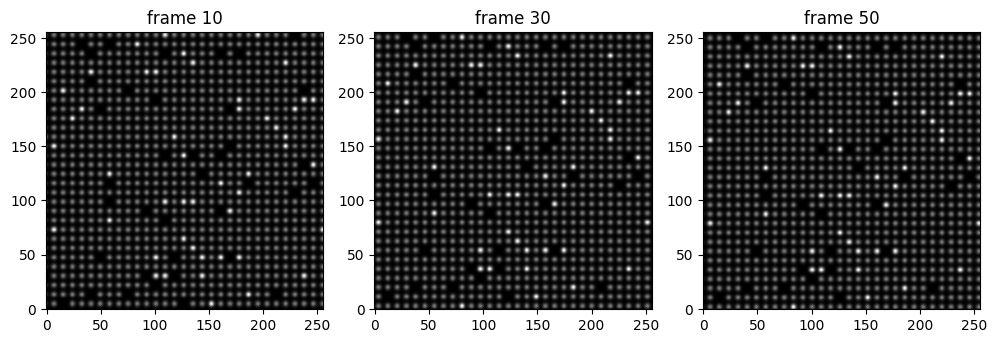

In [18]:
# Alternatively, you can specify what time steps and centers you want to image

# Example: same nominal center, three successive frames
img1 = get_image2(20, 50, i=10)
img2 = get_image2(20, 50, i=30)
img3 = get_image2(20, 50, i=50)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(img1, cmap='gray', origin='lower')
ax[0].set_title("frame 10")
ax[1].imshow(img2, cmap='gray', origin='lower')
ax[1].set_title("frame 30")
ax[2].imshow(img3, cmap='gray', origin='lower')
ax[2].set_title("frame 50")
plt.tight_layout()
plt.show()

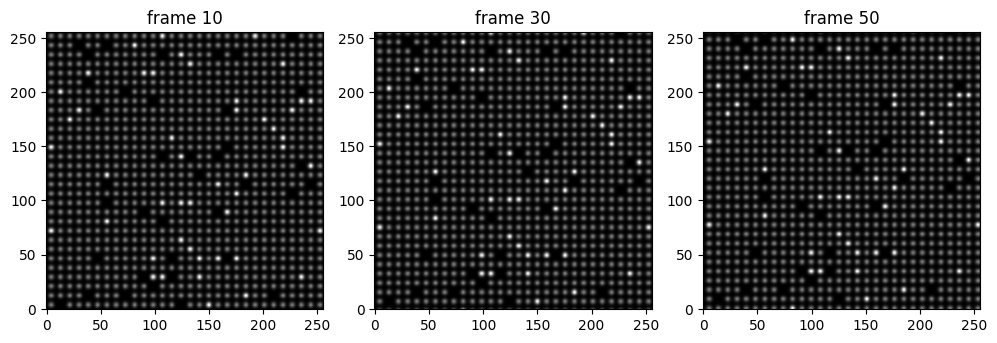

In [19]:
# Alternatively, you can specify what time steps and centers you want to image

# Example: same nominal center, three successive frames
img1 = get_image3(20, 50, i=10)
img2 = get_image3(20, 50, i=30)
img3 = get_image3(20, 50, i=50)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(img1, cmap='gray', origin='lower')
ax[0].set_title("frame 10")
ax[1].imshow(img2, cmap='gray', origin='lower')
ax[1].set_title("frame 30")
ax[2].imshow(img3, cmap='gray', origin='lower')
ax[2].set_title("frame 50")
plt.tight_layout()
plt.show()

# Visualize the drift fields

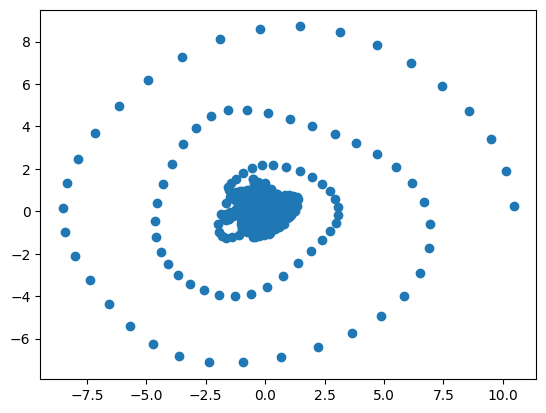

In [20]:
plt.scatter(get_drift_trace1()[0], get_drift_trace1()[1])

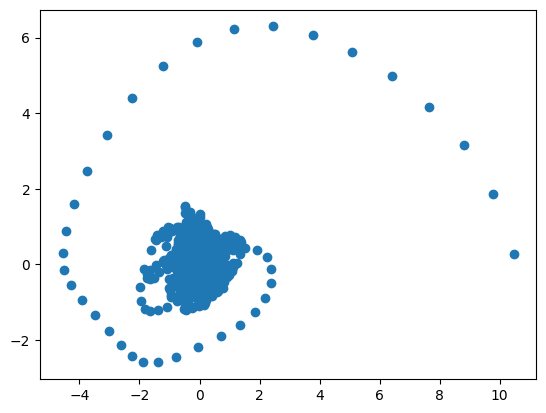

In [21]:
# mode-1:

plt.scatter(get_drift_trace2()[0], get_drift_trace2()[1])

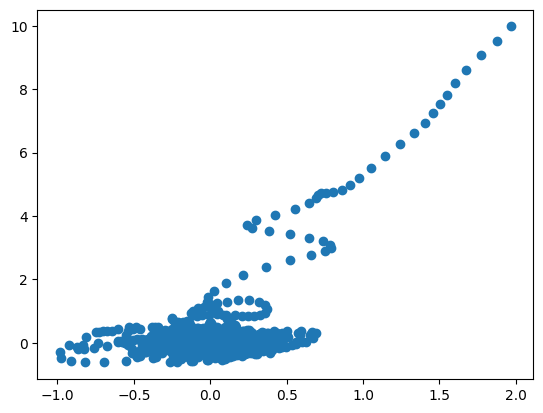

In [22]:
# mode-2:

plt.scatter(get_drift_trace3()[0], get_drift_trace3()[1])

# Midterm Part II

You have access to functions of the type:
- get_image1(x,y, i=10)
- get_image2(x,y, i=10)
- get_image3(x,y, i=10)

Here,
- image1, image2, and image3 correspond to the different drift histories.
- (x,y) correspond to the initial position of the beam, that it the center of the image taken by the microscope
- i = 10 is the time at which image is taken.

Step 1: Experiment with the images and how they look like if you change the position of the beam or change the time when image is acquired.

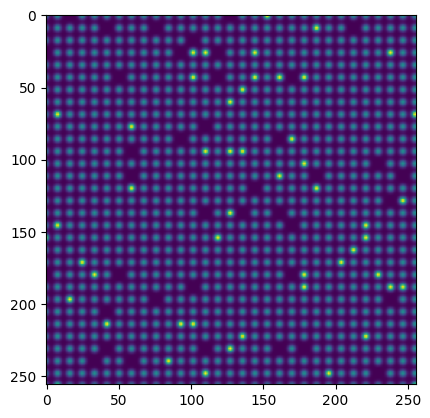

In [23]:
plt.imshow(get_image1(20, 51, i=10))

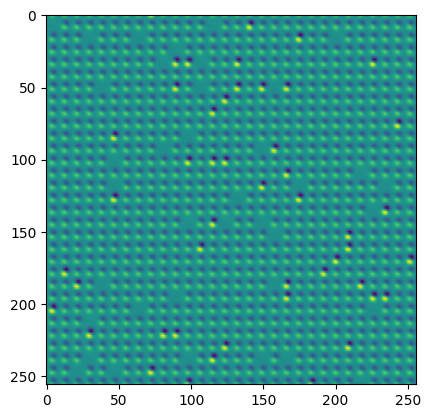

In [24]:
plt.imshow(get_image1(20, 50, i=1)- get_image1(20, 50, i=2))

## Task 1: Learning the drift trajectory

- Generate the sequence if images from i = 1 to 50, and learn the drift function from images
- Compare is to the ground truth (plot x and y components separately)
- Do it for all three trajectories

**Strategy.** Here we use the first acquired frame as the reference image. For every later frame at the same nominal beam position, we try to estimate the rigid image translation with phase correlation with window both images and compute their normalized cross-power spectrum in Fourier space. Then locate the inverse-FFT correlation peak. A small parabolic refinement around the peak gives sub-pixel x and y drift estimates. Because this gives drift relative to the reference frame, we compare it to the ground truth after subtracting the ground-truth drift at the first frame.


In [25]:
# Task 1 helper functions: learn relative drift from image translations.
def _hann2d(shape):
    return np.hanning(shape[0])[:, None] * np.hanning(shape[1])[None, :]


def phase_correlate(img_ref, img, win=None):
    """Return (dx, dy) shift of img relative to img_ref using phase correlation."""
    if win is None:
        win = _hann2d(img_ref.shape)

    a = (img_ref - np.mean(img_ref)) * win
    b = (img - np.mean(img)) * win
    f_ref = np.fft.fft2(a)
    f_img = np.fft.fft2(b)
    cross_power = f_ref * np.conj(f_img)
    cross_power /= np.abs(cross_power) + 1e-12
    corr = np.fft.ifft2(cross_power).real

    py, px = np.unravel_index(np.argmax(corr), corr.shape)
    ny, nx = corr.shape

    def parabolic_offset(center, left, right):
        denom = left - 2 * center + right
        if abs(denom) < 1e-12:
            return 0.0
        return 0.5 * (left - right) / denom

    dy_sub = parabolic_offset(corr[py, px], corr[(py - 1) % ny, px], corr[(py + 1) % ny, px])
    dx_sub = parabolic_offset(corr[py, px], corr[py, (px - 1) % nx], corr[py, (px + 1) % nx])

    dy = py + dy_sub
    dx = px + dx_sub
    if dy > ny // 2:
        dy -= ny
    if dx > nx // 2:
        dx -= nx
    return np.array([dx, dy], dtype=float)


def estimate_drift_series(get_image, frame_indices, x=0, y=0):
    """Estimate relative (dx, dy) drift for frame_indices from images only."""
    frames = [get_image(x, y, i=int(i)) for i in frame_indices]
    reference = frames[0]
    win = _hann2d(reference.shape)
    drift = np.zeros((len(frame_indices), 2), dtype=float)
    for j, frame in enumerate(frames):
        drift[j] = phase_correlate(reference, frame, win=win)
    return drift, frames


def relative_ground_truth(gt_drift_fn, frame_indices):
    gt = np.array([gt_drift_fn(int(i)) for i in frame_indices], dtype=float)
    return gt - gt[0]


In [26]:
frame_indices = np.arange(1, 51)
trajectory_getters = [
    (get_image1, gt_drift_fn1, "Trajectory 1"),
    (get_image2, gt_drift_fn2, "Trajectory 2"),
    (get_image3, gt_drift_fn3, "Trajectory 3"),
]

task1_results = []
for get_image, gt_drift_fn, label in trajectory_getters:
    learned_drift, frames = estimate_drift_series(get_image, frame_indices)
    gt_relative = relative_ground_truth(gt_drift_fn, frame_indices)
    rms_error = np.sqrt(np.mean(np.sum((learned_drift - gt_relative) ** 2, axis=1)))
    task1_results.append({
        "label": label,
        "learned_drift": learned_drift,
        "ground_truth": gt_relative,
        "frames": frames,
        "rms_error": rms_error,
    })
    print(f"{label}: image-registration RMS error = {rms_error:.3f} pixels")


Trajectory 1: image-registration RMS error = 0.156 pixels
Trajectory 2: image-registration RMS error = 0.145 pixels
Trajectory 3: image-registration RMS error = 0.119 pixels


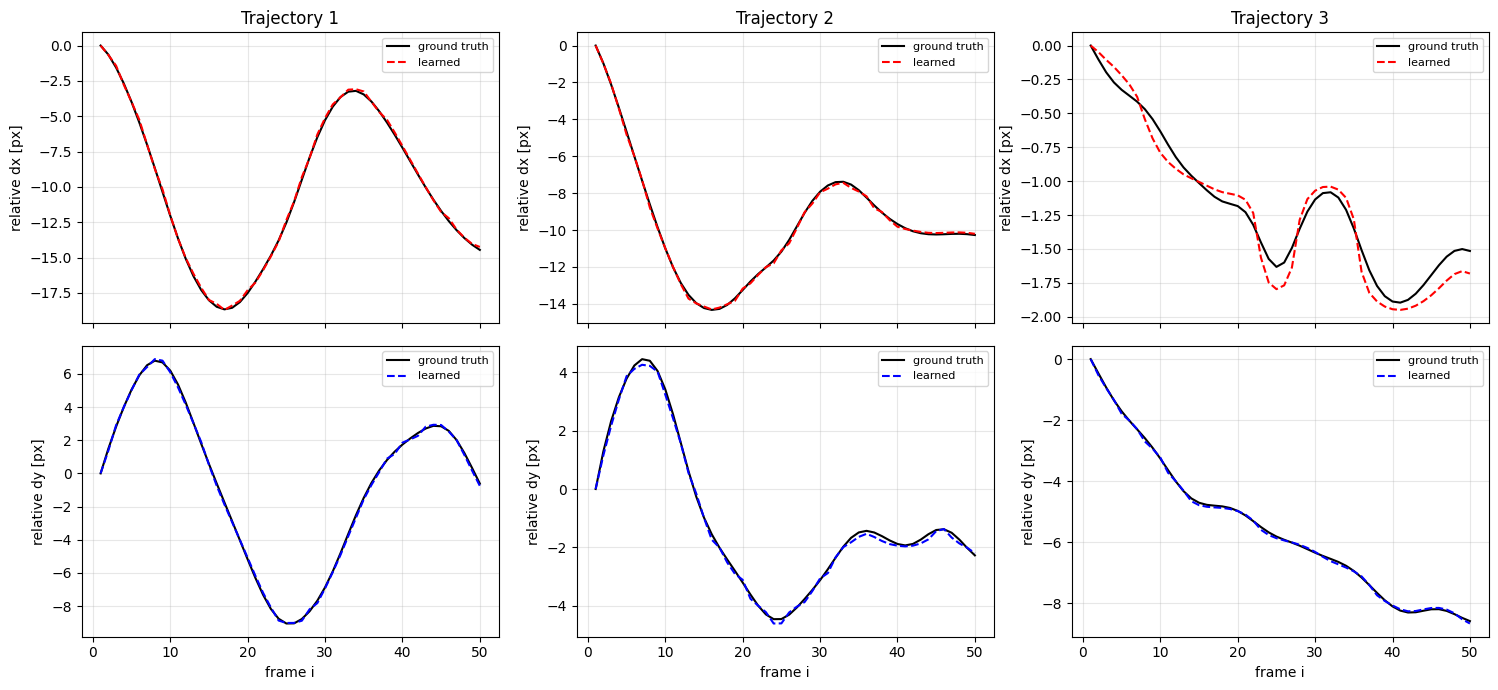

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for col, result in enumerate(task1_results):
    label = result["label"]
    learned = result["learned_drift"]
    gt = result["ground_truth"]

    axes[0, col].plot(frame_indices, gt[:, 0], "k-", label="ground truth")
    axes[0, col].plot(frame_indices, learned[:, 0], "r--", label="learned")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("relative dx [px]")
    axes[0, col].grid(alpha=0.3)
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(frame_indices, gt[:, 1], "k-", label="ground truth")
    axes[1, col].plot(frame_indices, learned[:, 1], "b--", label="learned")
    axes[1, col].set_xlabel("frame i")
    axes[1, col].set_ylabel("relative dy [px]")
    axes[1, col].grid(alpha=0.3)
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Task 2: Kalman filtering

- Use the Kalman filtering to predict the drift at next step
- Acquire data using Kalman filter as a part of the process (i.e. you acquire the image using x+dx, y+dy, where dx and dy is predicted position of the beam to avoid drift)
- Compare the predicted corrections to the ground truth.

**Strategy.** Here we model the drift state as `[dx, dy, vx, vy]`, where `dx, dy` are the current drift and `vx, vy` are the frame-to-frame drift rates. A constant-velocity Kalman filter predicts the next drift before each image is acquired. The predicted drift is used as a correction by acquiring the image at `x - dx_pred, y - dy_pred`, which keeps the true crop closer to the desired location. The remaining residual shift is then measured with phase correlation, added back to the prediction to form the Kalman measurement, and then used to update the filter. The predicted, updated, and residual corrections are compared with the ground truth.


In [28]:
# Task 2: constant-velocity Kalman filter for online drift tracking.
class KalmanDriftFilter:
    def __init__(self, process_var=0.25, measurement_var=0.25):
        self.state = np.zeros(4, dtype=float)  # [dx, dy, vx, vy]
        self.cov = np.eye(4) * 10.0
        self.transition = np.array([
            [1, 0, 1, 0],
            [0, 1, 0, 1],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
        ], dtype=float)
        self.observation = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0],
        ], dtype=float)
        self.process_noise = np.eye(4) * process_var
        self.measurement_noise = np.eye(2) * measurement_var

    def predict(self):
        self.state = self.transition @ self.state
        self.cov = self.transition @ self.cov @ self.transition.T + self.process_noise
        return self.state[:2].copy()

    def update(self, measurement):
        innovation = measurement - self.observation @ self.state
        innovation_cov = self.observation @ self.cov @ self.observation.T + self.measurement_noise
        gain = self.cov @ self.observation.T @ np.linalg.inv(innovation_cov)
        self.state = self.state + gain @ innovation
        self.cov = (np.eye(4) - gain @ self.observation) @ self.cov
        return self.state[:2].copy()


In [29]:
def kalman_compensation_loop(get_image, frame_indices, x=0, y=0,
                             process_var=0.25, measurement_var=0.25):
    """Acquire compensated images and update a Kalman drift estimate online."""
    reference_i = int(frame_indices[0])
    reference = get_image(x, y, i=reference_i)
    win = _hann2d(reference.shape)
    kf = KalmanDriftFilter(process_var=process_var, measurement_var=measurement_var)

    predicted = np.zeros((len(frame_indices), 2), dtype=float)
    measured = np.zeros_like(predicted)
    posterior = np.zeros_like(predicted)
    residual = np.zeros_like(predicted)

    for j, i in enumerate(frame_indices[1:], start=1):
        prediction = kf.predict()
        compensated_frame = get_image(x - prediction[0], y - prediction[1], i=int(i))
        residual_shift = phase_correlate(reference, compensated_frame, win=win)
        measurement = prediction + residual_shift
        posterior_estimate = kf.update(measurement)

        predicted[j] = prediction
        measured[j] = measurement
        posterior[j] = posterior_estimate
        residual[j] = residual_shift

    return predicted, measured, posterior, residual


In [30]:
task2_results = []
for get_image, gt_drift_fn, label in trajectory_getters:
    predicted, measured, posterior, residual = kalman_compensation_loop(get_image, frame_indices)
    gt_relative = relative_ground_truth(gt_drift_fn, frame_indices)
    prediction_rms = np.sqrt(np.mean(np.sum((predicted - gt_relative) ** 2, axis=1)))
    residual_rms = np.sqrt(np.mean(np.sum(residual ** 2, axis=1)))
    task2_results.append({
        "label": label,
        "predicted": predicted,
        "measured": measured,
        "posterior": posterior,
        "residual": residual,
        "ground_truth": gt_relative,
        "prediction_rms": prediction_rms,
        "residual_rms": residual_rms,
    })
    print(f"{label}: prediction RMS = {prediction_rms:.3f} px, compensated residual RMS = {residual_rms:.3f} px")


Trajectory 1: prediction RMS = 0.664 px, compensated residual RMS = 0.645 px
Trajectory 2: prediction RMS = 0.527 px, compensated residual RMS = 0.453 px
Trajectory 3: prediction RMS = 0.194 px, compensated residual RMS = 0.133 px


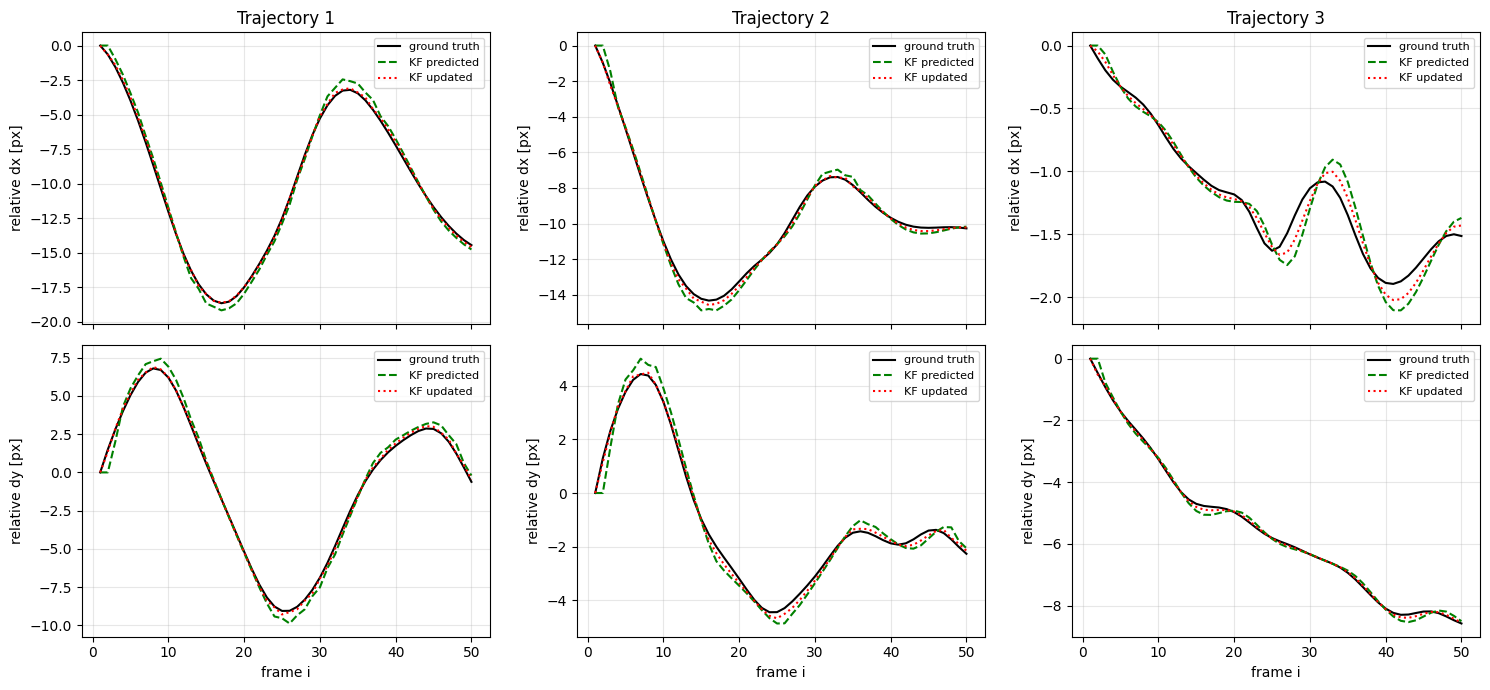

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for col, result in enumerate(task2_results):
    label = result["label"]
    gt = result["ground_truth"]
    pred = result["predicted"]
    post = result["posterior"]

    axes[0, col].plot(frame_indices, gt[:, 0], "k-", label="ground truth")
    axes[0, col].plot(frame_indices, pred[:, 0], "g--", label="KF predicted")
    axes[0, col].plot(frame_indices, post[:, 0], "r:", label="KF updated")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("relative dx [px]")
    axes[0, col].grid(alpha=0.3)
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(frame_indices, gt[:, 1], "k-", label="ground truth")
    axes[1, col].plot(frame_indices, pred[:, 1], "g--", label="KF predicted")
    axes[1, col].plot(frame_indices, post[:, 1], "r:", label="KF updated")
    axes[1, col].set_xlabel("frame i")
    axes[1, col].set_ylabel("relative dy [px]")
    axes[1, col].grid(alpha=0.3)
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()


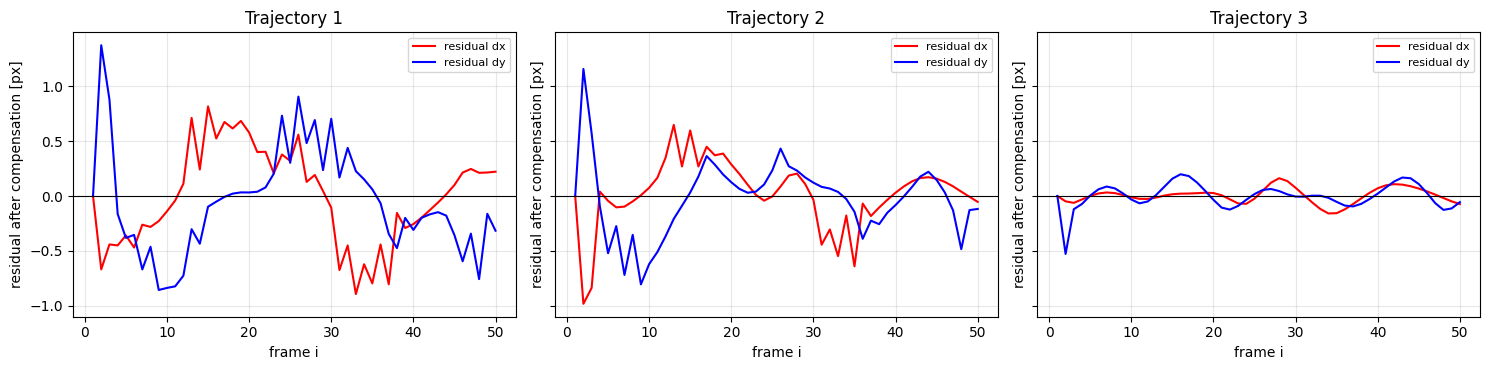

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharex=True, sharey=True)
for col, result in enumerate(task2_results):
    residual = result["residual"]
    axes[col].plot(frame_indices, residual[:, 0], "r-", label="residual dx")
    axes[col].plot(frame_indices, residual[:, 1], "b-", label="residual dy")
    axes[col].axhline(0, color="k", linewidth=0.8)
    axes[col].set_title(result["label"])
    axes[col].set_xlabel("frame i")
    axes[col].set_ylabel("residual after compensation [px]")
    axes[col].grid(alpha=0.3)
    axes[col].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Task 3: Predictive model

- Suggest possible algorithm to extrapolate drift, meaning build the predctive model
- Acquire data using the model (i.e. you acquire the image using x+dx, y+dy, where dx and dy is predicted position of the beam to avoid drift)
- Compare the predicted corrections to the ground truth.

**Strategy.** We first learn the early drift trajectory from the images using the same phase-correlation method as Task 1. Then build an adaptive predictive model by fitting a low-order polynomial to the most recent drift estimates and extrapolating one frame ahead. For each new frame, we use the model prediction as the beam correction, acquire the compensated image, measure the remaining residual shift by phase correlation, and append the corrected measurement back into the drift history.

In [33]:
# Task 3: predictive extrapolation with a rolling quadratic model.
def rolling_polynomial_predict(history, next_index, window=5, degree=2):
    """Predict the next (dx, dy) from recent drift history."""
    history = np.asarray(history, dtype=float)
    start = max(0, len(history) - window)
    t = np.arange(start, len(history), dtype=float)
    y = history[start:]
    degree_use = min(degree, len(t) - 1)

    if degree_use <= 0:
        return y[-1].copy()

    prediction = np.zeros(2, dtype=float)
    t_local = t - t[-1]
    next_local = float(next_index) - t[-1]
    for component in range(2):
        coeffs = np.polyfit(t_local, y[:, component], deg=degree_use)
        prediction[component] = np.polyval(coeffs, next_local)
    return prediction

In [34]:
def predictive_compensation_loop(get_image, frame_indices, train_count=30,
                                 window=5, degree=2, x=0, y=0):
    """Train on early images, then predict and compensate each next frame online."""
    train_indices = frame_indices[:train_count]
    training_drift, training_frames = estimate_drift_series(get_image, train_indices, x=x, y=y)
    reference = training_frames[0]
    win = _hann2d(reference.shape)

    predicted = np.zeros((len(frame_indices), 2), dtype=float)
    total_estimate = np.zeros_like(predicted)
    residual = np.zeros_like(predicted)
    predicted[:train_count] = training_drift
    total_estimate[:train_count] = training_drift
    history = list(training_drift)

    for j, i in enumerate(frame_indices[train_count:], start=train_count):
        prediction = rolling_polynomial_predict(history, j, window=window, degree=degree)
        compensated_frame = get_image(x - prediction[0], y - prediction[1], i=int(i))
        residual_shift = phase_correlate(reference, compensated_frame, win=win)
        measurement = prediction + residual_shift

        predicted[j] = prediction
        residual[j] = residual_shift
        total_estimate[j] = measurement
        history.append(measurement)

    return predicted, total_estimate, residual


In [35]:
train_count = 30
task3_results = []
for get_image, gt_drift_fn, label in trajectory_getters:
    predicted, total_estimate, residual = predictive_compensation_loop(
        get_image,
        frame_indices,
        train_count=train_count,
        window=5,
        degree=2,
    )
    gt_relative = relative_ground_truth(gt_drift_fn, frame_indices)
    test_slice = slice(train_count, None)
    prediction_rms = np.sqrt(np.mean(np.sum((predicted[test_slice] - gt_relative[test_slice]) ** 2, axis=1)))
    closed_loop_rms = np.sqrt(np.mean(np.sum((total_estimate[test_slice] - gt_relative[test_slice]) ** 2, axis=1)))
    residual_rms = np.sqrt(np.mean(np.sum(residual[test_slice] ** 2, axis=1)))
    task3_results.append({
        "label": label,
        "predicted": predicted,
        "total_estimate": total_estimate,
        "residual": residual,
        "ground_truth": gt_relative,
        "prediction_rms": prediction_rms,
        "closed_loop_rms": closed_loop_rms,
        "residual_rms": residual_rms,
    })
    print(f"{label}: extrapolation RMS = {prediction_rms:.3f} px, closed-loop RMS = {closed_loop_rms:.3f} px, residual RMS = {residual_rms:.3f} px")


Trajectory 1: extrapolation RMS = 0.315 px, closed-loop RMS = 0.123 px, residual RMS = 0.221 px
Trajectory 2: extrapolation RMS = 0.307 px, closed-loop RMS = 0.131 px, residual RMS = 0.186 px
Trajectory 3: extrapolation RMS = 0.132 px, closed-loop RMS = 0.055 px, residual RMS = 0.081 px


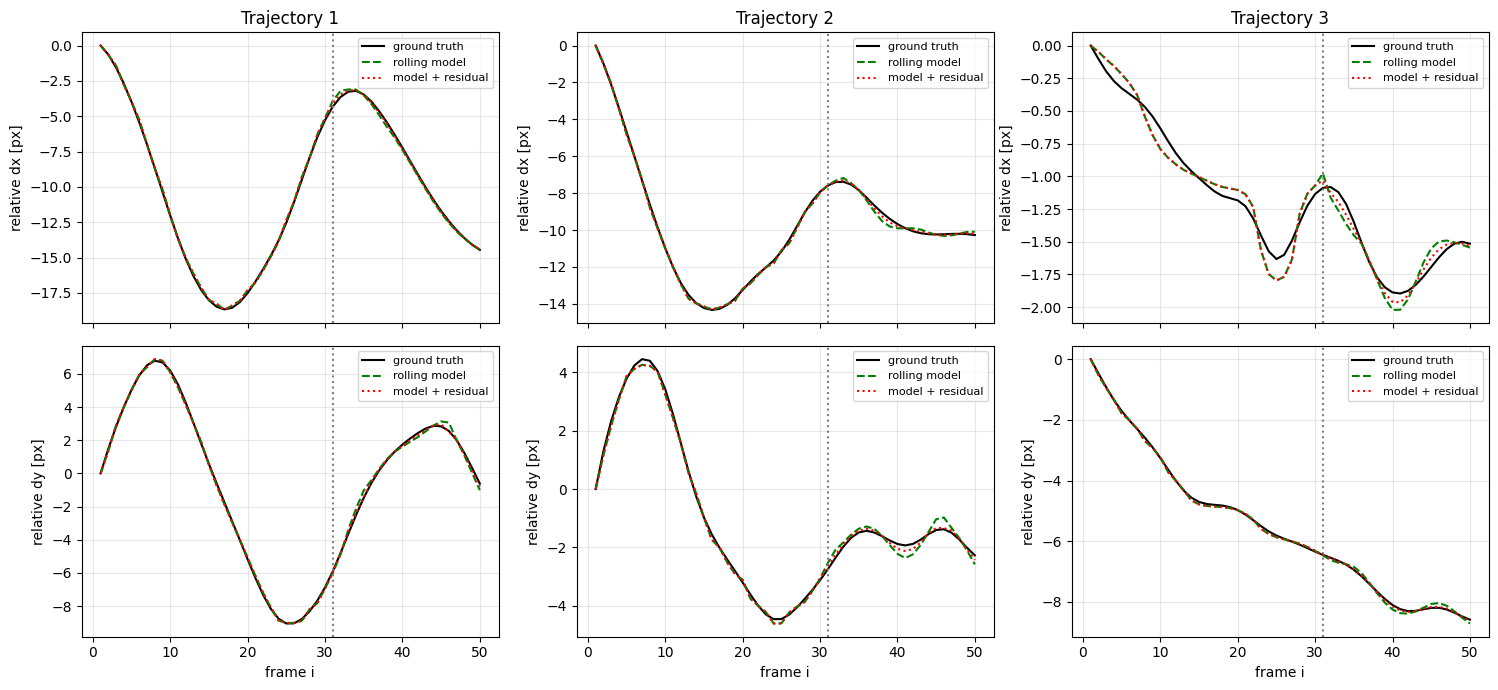

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for col, result in enumerate(task3_results):
    label = result["label"]
    gt = result["ground_truth"]
    pred = result["predicted"]
    total = result["total_estimate"]

    axes[0, col].plot(frame_indices, gt[:, 0], "k-", label="ground truth")
    axes[0, col].plot(frame_indices, pred[:, 0], "g--", label="rolling model")
    axes[0, col].plot(frame_indices, total[:, 0], "r:", label="model + residual")
    axes[0, col].axvline(frame_indices[train_count], color="0.5", linestyle=":")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("relative dx [px]")
    axes[0, col].grid(alpha=0.3)
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(frame_indices, gt[:, 1], "k-", label="ground truth")
    axes[1, col].plot(frame_indices, pred[:, 1], "g--", label="rolling model")
    axes[1, col].plot(frame_indices, total[:, 1], "r:", label="model + residual")
    axes[1, col].axvline(frame_indices[train_count], color="0.5", linestyle=":")
    axes[1, col].set_xlabel("frame i")
    axes[1, col].set_ylabel("relative dy [px]")
    axes[1, col].grid(alpha=0.3)
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()
